# Tc from McMillan, Allen–Dynes, Eliashberg and SCDFT on one model

The four ab-initio routes to $T_c$ disagree in ways that are hard to attribute
when each is applied to a different material. On a model where every ingredient
is exact by construction they can be compared directly, which is the purpose of
Fig. 2 of the supplementary information of *Ab initio methods for
superconductivity* (Nature Rev. Phys. **6**, 570 (2024)); this notebook
reproduces it.

The model is the one the McMillan and Allen–Dynes formulas themselves assume:

* a constant electronic density of states over $[-E_F, E_F]$ with $E_F = 5$ eV,
* a single Einstein phonon at $\omega_{\log}$, so
  $\alpha^2F(\omega) = \tfrac{\lambda\,\omega_{\log}}{2}\,\delta(\omega-\omega_{\log})$
  and $\lambda = 2\int\alpha^2F/\omega\,d\omega$ exactly,
* a Coulomb interaction constant over the band, so the $\mu^*$ approximation is
  exact rather than an approximation.

Three families are shown, $(\omega_{\log}, \mu^*) = (80\ \mathrm{meV}, 0.1)$,
$(20\ \mathrm{meV}, 0)$ and $(20\ \mathrm{meV}, 0.1)$, over $\lambda \in [0, 2]$.

In [1]:
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from waw.analysis.eliashberg import allen_dynes_tc
from waw.utils.eliashberg import rescale_mu_star, tc_linearized
from waw.utils.scdft import tc_scdft
from waw.units import EV_TO_HARTREE, HARTREE_TO_EV, K_B_HARTREE

E_FERMI = 5.0 * EV_TO_HARTREE          # half-width of the constant-DOS window
LAMBDAS = np.array([0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 1.3, 1.6, 2.0])
FAMILIES = [(80e-3 * EV_TO_HARTREE, 0.1), (20e-3 * EV_TO_HARTREE, 0.0),
            (20e-3 * EV_TO_HARTREE, 0.1)]
OMEGA_C_MU = 0.1 * EV_TO_HARTREE       # the cutoff mu* is quoted at, fixed
print(f'E_F = {E_FERMI * HARTREE_TO_EV:.1f} eV, '
      f'omega_log = {[round(w * HARTREE_TO_EV * 1e3) for w, _ in FAMILIES]} meV')

E_F = 5.0 eV, omega_log = [80, 20, 20] meV


### $\mu$ and $\mu^*$ are different quantities, and the methods want different ones

The Coulomb repulsion enters as a constant $\mu$ over the full band — the
*unrenormalized* pseudopotential, the density of states at $E_F$ times the
averaged interaction. Eliashberg theory cannot use that directly: it truncates
its Matsubara sum at $\omega_c$, and the repulsion has to be renormalized down
to that cutoff, giving the Morel–Anderson $\mu^*$,

$$\mu^*(\omega_c) = \frac{\mu}{1 + \mu\,\ln(E_F/\omega_c)}.$$

SCDFT needs no such step — it keeps the full energy dependence of the
interaction — so it takes $\mu$ itself over $[-E_F, E_F]$. Sanna, Pellegrini and
Gross set their comparison up exactly this way: $\mu = 0.223$ and $0.394$ over a
$\pm10$ eV window become $\mu^* = 0.11$ and $0.14$ at a 0.1 eV cutoff.

Feeding one method the other's number is a real error rather than a nicety.
The families are labelled by $\mu^*$ at a **fixed** cutoff of 0.1 eV, which is
the convention Sanna, Pellegrini and Gross state for their own comparison. That
cutoff does not follow $\omega_{\log}$, so a single $\mu = 0.164$ over $\pm5$ eV
serves both families — as it should, $\mu$ being a property of the electrons and
not of the phonons. McMillan and Allen–Dynes take $\mu^*$ as given, Eliashberg
takes it renormalized to its own $\omega_c = 10\,\omega_{\log}$, and SCDFT takes
$\mu$.

A constant $\mu$ is meaningless without the window it is constant over, exactly as $\mu^*$ is meaningless without $\omega_c$. The Coulomb kernel is therefore the windowed constant

$$W(\xi,\xi') = \mu\,\Theta(\Lambda - |\xi|)\,\Theta(\Lambda - |\xi'|),\qquad \Lambda = E_F$$

passed as `mu_cutoff`. Both step functions do work: the one on $\xi'$ cuts the logarithmically divergent energy integral, and the one on $\xi$ removes the repulsion outside the window, which is what leaves the two-square-well structure behind the Morel–Anderson formula above.

### The $\xi'$ integration range is a second window, and here it is $E_F$ too

The energy range the $\xi'$ integral itself runs over is independent of $\Lambda$
and is passed as `cutoff`. For this model it is not a convergence knob but part
of the definition: the density of states is constant on $[-E_F, E_F]$ and zero
outside, so both the phonon and the Coulomb kernel integrate over exactly that
band.

It has to be said out loud rather than left to the default, for two reasons.
First, it matters: both SCDFT kernels have power-law tails in $\xi'$, so $T_c$
approaches its wide-band limit only as $1/\mathrm{cutoff}$ — on the phonon-only
Einstein model a range of $30\,\omega_{\log}$ overestimates $T_c$ by 3% at
$\lambda = 0.4$ and by 6% at $\lambda = 2.8$, a $\lambda$-dependent error that is
easily mistaken for physics. Second, the default is a multiple of $\omega_{\log}$,
so leaving it implicit would give the 20 and 80 meV families *different*
electronic windows (8 eV against 32 eV) — exactly the confusion the paragraph
above warns about for $\mu$, and fatal to a comparison whose whole point is that
only the phonon energy changes between them. Passing `cutoff=E_FERMI` puts all
three families on one band.

In [2]:
def a2f_einstein(omega_log, lam, n=600, width_frac=0.01):
    '''alpha^2F for an Einstein mode, as a narrow Gaussian on a grid.'''
    w = np.linspace(0.2 * omega_log, 2.0 * omega_log, n)
    sigma = width_frac * omega_log
    a2f = (lam * omega_log / 2) * np.exp(-0.5 * ((w - omega_log) / sigma) ** 2) / (
        sigma * np.sqrt(2 * np.pi))
    return w, a2f

rows = []
for omega_log, mu_mcm in FAMILIES:
    omega_c = 10.0 * omega_log                     # Eliashberg cutoff
    # The family label is mu* at the PHONON scale, which is what McMillan and
    # Allen-Dynes take. Two derived quantities follow from it: mu*(omega_c) for
    # Eliashberg (larger, review Eq. 30), and mu over the band for SCDFT
    # (larger still, since it is not renormalized at all).
    mu_el = rescale_mu_star(mu_mcm, OMEGA_C_MU, omega_c) if mu_mcm else 0.0
    mu_band = (mu_mcm / (1.0 - mu_mcm * np.log(E_FERMI / OMEGA_C_MU))
               if mu_mcm else 0.0)
    for lam in LAMBDAS:
        # McMillan and Allen-Dynes: omega_2 = omega_log for a single mode, so
        # Allen-Dynes reduces to McMillan times its strong-coupling factor f1
        denom = lam - mu_mcm * (1 + 0.62 * lam)
        tc_mcm = (omega_log / 1.2 * np.exp(-1.04 * (1 + lam) / denom) / K_B_HARTREE
                  if denom > 0 else 0.0)
        tc_ad = allen_dynes_tc(lam, omega_log, omega_log, mu_mcm) / K_B_HARTREE
        w, a2f = a2f_einstein(omega_log, lam)
        tc_el = tc_linearized(a2f, w, mu_el, omega_c=omega_c,
                              n_matsubara=512).tc
        # cutoff = the band the xi' integral runs over, mu_cutoff = the window mu
        # is constant over. Both are E_F for this model, and both are stated
        # rather than defaulted: the default cutoff scales with omega_log, which
        # would give the two families different bands.
        tc_sc = tc_scdft(np.array([omega_log]), np.array([[[lam * omega_log / 2]]]),
                         mu_band, cutoff=E_FERMI, mu_cutoff=E_FERMI, n_points=140)
        rows.append((omega_log, mu_mcm, lam, tc_mcm, tc_ad, tc_el, tc_sc))
        print(f'wlog={omega_log*HARTREE_TO_EV*1e3:4.0f} meV mu*={mu_mcm:.1f} '
              f'(mu={mu_band:.3f}) '
              f'lam={lam:.2f}: McM {tc_mcm:6.1f}  AD {tc_ad:6.1f}  '
              f'Eliash {tc_el:6.1f}  SCDFT {tc_sc:6.1f} K', flush=True)
rows = np.array(rows)

wlog=  80 meV mu*=0.1 (mu=0.164) lam=0.20: McM    0.0  AD    0.0  Eliash    0.0  SCDFT    0.0 K


wlog=  80 meV mu*=0.1 (mu=0.164) lam=0.30: McM    0.4  AD    0.5  Eliash    0.4  SCDFT    1.6 K


wlog=  80 meV mu*=0.1 (mu=0.164) lam=0.40: McM    3.9  AD    3.9  Eliash    4.0  SCDFT    6.5 K


wlog=  80 meV mu*=0.1 (mu=0.164) lam=0.50: McM   11.3  AD   11.5  Eliash   11.4  SCDFT   14.1 K


wlog=  80 meV mu*=0.1 (mu=0.164) lam=0.70: McM   32.3  AD   33.3  Eliash   33.0  SCDFT   32.1 K


...

wlog=  20 meV mu*=0.1 (mu=0.164) lam=0.70: McM    8.1  AD    8.3  Eliash    9.1  SCDFT    8.8 K


wlog=  20 meV mu*=0.1 (mu=0.164) lam=1.00: McM   16.2  AD   17.0  Eliash   18.1  SCDFT   15.7 K


wlog=  20 meV mu*=0.1 (mu=0.164) lam=1.30: McM   22.8  AD   24.5  Eliash   25.7  SCDFT   21.7 K


wlog=  20 meV mu*=0.1 (mu=0.164) lam=1.60: McM   28.1  AD   30.8  Eliash   32.2  SCDFT   27.0 K


wlog=  20 meV mu*=0.1 (mu=0.164) lam=2.00: McM   33.4  AD   37.8  Eliash   39.4  SCDFT   33.1 K


### Fig. 2b reproduced

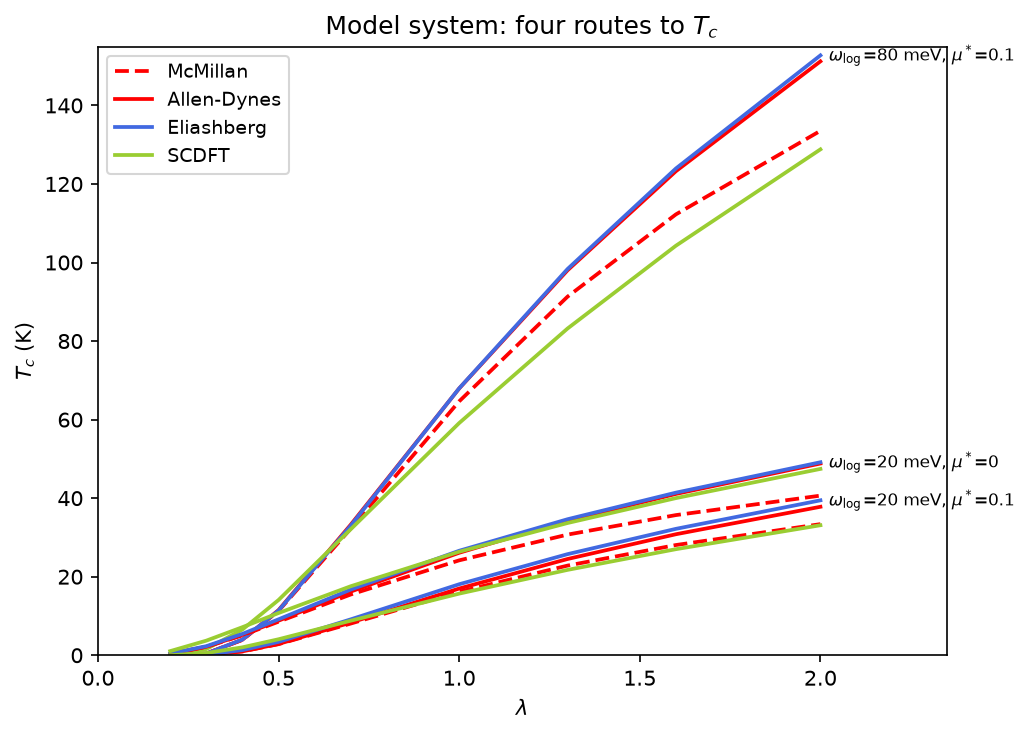

In [3]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
STYLE = [('McMillan', 3, 'red', '--'), ('Allen-Dynes', 4, 'red', '-'),
         ('Eliashberg', 5, 'royalblue', '-'), ('SCDFT', 6, 'yellowgreen', '-')]
for omega_log, mu in FAMILIES:
    sel = (rows[:, 0] == omega_log) & (rows[:, 1] == mu)
    for label, col, colour, ls in STYLE:
        first = (omega_log, mu) == FAMILIES[0]
        ax.plot(rows[sel, 2], rows[sel, col], ls, color=colour, lw=1.8,
                label=label if first else None)
    x, y = rows[sel, 2][-1], rows[sel, 5][-1]
    ax.annotate(rf'$\omega_{{\log}}$={omega_log*HARTREE_TO_EV*1e3:.0f} meV, '
                rf'$\mu^*$={mu:g}', (x, y), xytext=(4, 0),
                textcoords='offset points', fontsize=8, va='center')
ax.set_xlabel(r'$\lambda$'); ax.set_ylabel(r'$T_c$ (K)')
ax.set_xlim(0, 2.35); ax.set_ylim(0, 155)
ax.legend(fontsize=9, loc='upper left')
ax.set_title('Model system: four routes to $T_c$')
plt.tight_layout(); plt.show()

### How the four compare, and where this implementation stands

Allen–Dynes sits above McMillan by its strong-coupling factor $f_1$ ($f_2 = 1$
here, the second moment of a single mode being $\omega_{\log}$ itself), and both
track Eliashberg closely once $\mu^*$ has been moved to the right cutoff.

SCDFT tracks them closely and runs slightly below at strong coupling, the same
direction reported for Nb, where "the SCDFT $T_c$, at which the gap closes, is a
few Kelvins lower".

SCDFT tracks McMillan closely in the two families with a finite $\mu$, both
running below Allen–Dynes and Eliashberg, which is how the published curves lie.
The residual is a few per cent, largest for $\omega_{\log} = 80$ meV where the
0.1 eV cutoff sits barely above the phonon energy and the Morel–Anderson
inversion is least comfortable.

At small $\lambda$ SCDFT overshoots. This is the functional's own documented
behaviour, not a numerical artefact: its supplementary material states that
"relative deviations from the Eliashberg results are bigger in the very weak
coupling limit. In this regime our functional slightly overestimates $T_c$",
and $\gamma_3$ was fitted over $0.4 < \lambda < 3.0$, so the smallest couplings
plotted here lie below the range the parametrization was optimized for.

In [4]:
# What giving SCDFT the wrong one of the two costs. mu* is renormalized down to
# the Eliashberg cutoff and is the SMALLER number, so handing it to SCDFT
# understates the repulsion and raises Tc.
omega_log, mu_star = FAMILIES[2]
omega_c = 10.0 * omega_log
mu_band = mu_star / (1.0 - mu_star * np.log(E_FERMI / OMEGA_C_MU))
print(f'omega_log = 20 meV: mu*(omega_c) = {mu_star:.4f}  <->  mu over the band '
      f'= {mu_band:.4f}')
for lam in (0.5, 1.0, 2.0):
    w, a2f = a2f_einstein(omega_log, lam)
    tc_el = tc_linearized(a2f, w, rescale_mu_star(mu_star, OMEGA_C_MU, omega_c),
                          omega_c=omega_c, n_matsubara=512).tc
    a = np.array([[[lam * omega_log / 2]]]); om = np.array([omega_log])
    kw = dict(cutoff=E_FERMI, mu_cutoff=E_FERMI, n_points=140)
    tc_mu = tc_scdft(om, a, mu_band, **kw)
    tc_ms = tc_scdft(om, a, mu_star, **kw)
    print(f'  lambda={lam:.1f}: Eliashberg {tc_el:6.2f} | SCDFT with mu '
          f'{tc_mu:6.2f} | with mu* by mistake {tc_ms:6.2f} K')

omega_log = 20 meV: mu*(omega_c) = 0.1000  <->  mu over the band = 0.1643


  lambda=0.5: Eliashberg   3.40 | SCDFT with mu   4.07 | with mu* by mistake   5.45 K


  lambda=1.0: Eliashberg  18.08 | SCDFT with mu  15.69 | with mu* by mistake  18.22 K


  lambda=2.0: Eliashberg  39.45 | SCDFT with mu  33.10 | with mu* by mistake  36.64 K
